In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import sem
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Analysis Plan:
# 1. Implement the Davenport-Heilbronn function and Riemann zeta function
# 2. Implement the R_comp metric (mean resultant length of composite squarefree terms)
# 3. Select resonance locations:
# - L_DH: t=114.16 (known off-line zero location)
# - zeta: find a high-magnitude peak in the same range
# 4. Compute R_comp(N) for N = 10^4, 5*10^4, 10^5, 5*10^5, 10^6
# 5. Fit power-law and log-correlated models
# 6. Use AIC for model selection
# 7. Report results

print("="*80)
print("ANALYSIS PLAN: Scaling Behavior of R_comp Metric")
print("="*80)
print()
print("Step 1: Implement coefficient functions for L_DH and ζ")
print("Step 2: Implement R_comp metric for composite squarefree terms")
print("Step 3: Select resonance locations:")
print(" - L_DH: t = 114.16 (known off-line zero)")
print(" - ζ: Find high-magnitude peak in similar t-range")
print("Step 4: Compute R_comp(N) for N in [10^4, 5×10^4, 10^5, 5×10^5, 10^6]")
print("Step 5: Fit power-law: R_comp(N) = c * N^α")
print("Step 6: Fit log-correlated: R_comp(N) = c * exp(k * sqrt(log N))")
print("Step 7: Use AIC for model selection")
print("="*80)


ANALYSIS PLAN: Scaling Behavior of R_comp Metric

Step 1: Implement coefficient functions for L_DH and ζ
Step 2: Implement R_comp metric for composite squarefree terms
Step 3: Select resonance locations:
 - L_DH: t = 114.16 (known off-line zero)
 - ζ: Find high-magnitude peak in similar t-range
Step 4: Compute R_comp(N) for N in [10^4, 5×10^4, 10^5, 5×10^5, 10^6]
Step 5: Fit power-law: R_comp(N) = c * N^α
Step 6: Fit log-correlated: R_comp(N) = c * exp(k * sqrt(log N))
Step 7: Use AIC for model selection


In [2]:

# Helper functions for number-theoretic operations

def sieve_of_eratosthenes(limit):
 """Generate all primes up to limit using sieve"""
 if limit < 2:
 return []
 is_prime = np.ones(limit + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 for i in range(2, int(np.sqrt(limit)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 return np.where(is_prime)[0]

def prime_factorization_squarefree(n_max):
 """
 For each n <= n_max, determine:
 - is_squarefree[n]: whether n is squarefree
 - omega[n]: number of distinct prime factors
 """
 is_squarefree = np.ones(n_max + 1, dtype=bool)
 omega = np.zeros(n_max + 1, dtype=int)
 
 primes = sieve_of_eratosthenes(n_max)
 
 for p in primes:
 # Mark multiples of p as having p as a factor
 omega[p::p] += 1
 # Mark multiples of p^2 as not squarefree
 if p * p <= n_max:
 is_squarefree[p*p::p*p] = False
 
 return is_squarefree, omega

def chi_mod5(n):
 """Complex character mod 5 of order 4"""
 n_mod = n % 5
 if n_mod == 0:
 return 0
 elif n_mod == 1:
 return 1
 elif n_mod == 2:
 return 1j
 elif n_mod == 3:
 return -1j
 elif n_mod == 4:
 return -1

def get_LDH_coefficients(n_max):
 """
 Compute Davenport-Heilbronn coefficients up to n_max.
 L_DH(s) = (1-iκ)/2 * L(s,χ) + (1+iκ)/2 * L(s,χ̄)
 where κ = (√5-1) / (2√(5(√5-1)))
 
 Only squarefree n have non-zero coefficients.
 """
 sqrt5 = np.sqrt(5)
 kappa = (sqrt5 - 1) / (2 * np.sqrt(5 * (sqrt5 - 1)))
 
 is_squarefree, _ = prime_factorization_squarefree(n_max)
 
 a = np.zeros(n_max + 1, dtype=complex)
 for n in range(1, n_max + 1):
 if is_squarefree[n]:
 chi_n = chi_mod5(n)
 chi_bar_n = np.conj(chi_n)
 a[n] = (1 - 1j*kappa)/2 * chi_n + (1 + 1j*kappa)/2 * chi_bar_n
 
 return a

def get_zeta_coefficients(n_max):
 """Riemann zeta coefficients: a_n = 1 for all n"""
 return np.ones(n_max + 1, dtype=complex)

print("Implemented helper functions:")
print(" - sieve_of_eratosthenes")
print(" - prime_factorization_squarefree")
print(" - chi_mod5")
print(" - get_LDH_coefficients")
print(" - get_zeta_coefficients")


Implemented helper functions:
 - sieve_of_eratosthenes
 - prime_factorization_squarefree
 - chi_mod5
 - get_LDH_coefficients
 - get_zeta_coefficients


In [3]:

def compute_D(t, N, coefficients):
 """
 Compute the partial sum D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 
 Args:
 t: height parameter
 N: truncation length
 coefficients: array of a_n values (index n corresponds to coefficient a_n)
 
 Returns:
 Complex value of D_F(t; N)
 """
 n = np.arange(1, N + 1)
 # Compute n^(1/2 + it) = n^(1/2) * n^(it) = sqrt(n) * exp(it log n)
 divisor = np.sqrt(n) * np.exp(1j * t * np.log(n))
 
 # Sum a_n / n^(1/2 + it)
 D = np.sum(coefficients[1:N+1] / divisor)
 return D

def compute_R_comp(t, N, coefficients):
 """
 Compute the R_comp metric: mean resultant length of composite squarefree terms.
 
 R_comp = |Σ (a_n / n^(1/2+it))| / Σ |a_n / n^(1/2+it)|
 where the sum is over composite squarefree n.
 
 Args:
 t: height parameter
 N: truncation length
 coefficients: array of a_n values
 
 Returns:
 R_comp value (real, between 0 and 1)
 """
 is_squarefree, omega = prime_factorization_squarefree(N)
 primes = sieve_of_eratosthenes(N)
 is_prime = np.zeros(N + 1, dtype=bool)
 is_prime[primes] = True
 
 # Composite squarefree: squarefree AND not prime AND n > 1
 is_composite_squarefree = is_squarefree & (~is_prime) & (np.arange(N + 1) > 1)
 
 # Get indices of composite squarefree numbers
 comp_sf_indices = np.where(is_composite_squarefree)[0]
 
 if len(comp_sf_indices) == 0:
 return 0.0
 
 # Compute terms
 terms = np.zeros(len(comp_sf_indices), dtype=complex)
 for i, n in enumerate(comp_sf_indices):
 divisor = np.sqrt(n) * np.exp(1j * t * np.log(n))
 terms[i] = coefficients[n] / divisor
 
 # R_comp = |sum| / sum(|.|)
 numerator = np.abs(np.sum(terms))
 denominator = np.sum(np.abs(terms))
 
 if denominator == 0:
 return 0.0
 
 return numerator / denominator

print("Implemented computation functions:")
print(" - compute_D: partial sum D_F(t; N)")
print(" - compute_R_comp: mean resultant length of composite squarefree terms")


Implemented computation functions:
 - compute_D: partial sum D_F(t; N)
 - compute_R_comp: mean resultant length of composite squarefree terms


In [4]:

# Step 1: Find high-magnitude peak for zeta in the range around t=114.16
# We'll scan a range around t=114.16 to find the highest |D_zeta(t; N)| for a moderate N

print("="*80)
print("STEP 1: Finding resonance locations")
print("="*80)
print()

# For L_DH, use the known off-line zero location
t_LDH = 114.16
print(f"L_DH resonance location (known off-line zero): t = {t_LDH}")

# For zeta, scan a range to find a high peak
# Use a moderate N for scanning (N=10^5)
N_scan = 100000
print(f"\nScanning for zeta peak in range [100, 150] with N = {N_scan:,}")

# Get coefficients
print("Computing zeta coefficients...")
zeta_coeffs = get_zeta_coefficients(N_scan)

# Scan t values
t_values = np.linspace(100, 150, 500)
D_zeta_values = np.zeros(len(t_values), dtype=complex)

print("Computing |D_zeta(t)| for t in [100, 150]...")
for i, t in enumerate(t_values):
 D_zeta_values[i] = compute_D(t, N_scan, zeta_coeffs)
 if (i + 1) % 100 == 0:
 print(f" Progress: {i+1}/{len(t_values)}")

# Find peak
magnitudes = np.abs(D_zeta_values)
peak_idx = np.argmax(magnitudes)
t_zeta = t_values[peak_idx]
peak_magnitude = magnitudes[peak_idx]

print(f"\nζ resonance location (highest peak): t = {t_zeta:.4f}")
print(f" Peak magnitude: |D_ζ(t)| = {peak_magnitude:.4f}")
print()
print(f"Selected resonance locations:")
print(f" L_DH: t = {t_LDH}")
print(f" ζ: t = {t_zeta:.4f}")


STEP 1: Finding resonance locations

L_DH resonance location (known off-line zero): t = 114.16

Scanning for zeta peak in range [100, 150] with N = 100,000
Computing zeta coefficients...
Computing |D_zeta(t)| for t in [100, 150]...


 Progress: 100/500


 Progress: 200/500


 Progress: 300/500


 Progress: 400/500


 Progress: 500/500

ζ resonance location (highest peak): t = 108.7174
 Peak magnitude: |D_ζ(t)| = 7.9216

Selected resonance locations:
 L_DH: t = 114.16
 ζ: t = 108.7174


In [5]:

# Step 2: Compute R_comp(N) for both functions at their respective t locations
# N values: 10^4, 5*10^4, 10^5, 5*10^5, 10^6

print("="*80)
print("STEP 2: Computing R_comp(N) for varying truncation lengths")
print("="*80)
print()

N_values = np.array([10000, 50000, 100000, 500000, 1000000])
print(f"N values: {N_values}")
print(f"L_DH at t = {t_LDH}")
print(f"ζ at t = {t_zeta:.4f}")
print()

R_comp_LDH = np.zeros(len(N_values))
R_comp_zeta = np.zeros(len(N_values))

for i, N in enumerate(N_values):
 print(f"\nComputing for N = {N:,}...")
 
 # Get coefficients up to N
 print(f" Computing L_DH coefficients...")
 LDH_coeffs = get_LDH_coefficients(N)
 
 print(f" Computing zeta coefficients...")
 zeta_coeffs = get_zeta_coefficients(N)
 
 # Compute R_comp for L_DH
 print(f" Computing R_comp for L_DH at t = {t_LDH}...")
 R_comp_LDH[i] = compute_R_comp(t_LDH, N, LDH_coeffs)
 
 # Compute R_comp for zeta
 print(f" Computing R_comp for ζ at t = {t_zeta:.4f}...")
 R_comp_zeta[i] = compute_R_comp(t_zeta, N, zeta_coeffs)
 
 print(f" Results: R_comp(L_DH) = {R_comp_LDH[i]:.6f}, R_comp(ζ) = {R_comp_zeta[i]:.6f}")

print("\n" + "="*80)
print("SUMMARY: R_comp values")
print("="*80)
results_df = pd.DataFrame({
 'N': N_values,
 'R_comp_LDH': R_comp_LDH,
 'R_comp_zeta': R_comp_zeta,
 'Ratio (LDH/zeta)': R_comp_LDH / R_comp_zeta
})
print(results_df.to_string(index=False))


STEP 2: Computing R_comp(N) for varying truncation lengths

N values: [ 10000 50000 100000 500000 1000000]
L_DH at t = 114.16
ζ at t = 108.7174


Computing for N = 10,000...
 Computing L_DH coefficients...
 Computing zeta coefficients...
 Computing R_comp for L_DH at t = 114.16...
 Computing R_comp for ζ at t = 108.7174...
 Results: R_comp(L_DH) = 0.009338, R_comp(ζ) = 0.004909

Computing for N = 50,000...
 Computing L_DH coefficients...
 Computing zeta coefficients...
 Computing R_comp for L_DH at t = 114.16...


 Computing R_comp for ζ at t = 108.7174...
 Results: R_comp(L_DH) = 0.005459, R_comp(ζ) = 0.004348

Computing for N = 100,000...
 Computing L_DH coefficients...


 Computing zeta coefficients...
 Computing R_comp for L_DH at t = 114.16...


 Computing R_comp for ζ at t = 108.7174...


 Results: R_comp(L_DH) = 0.004681, R_comp(ζ) = 0.004757

Computing for N = 500,000...
 Computing L_DH coefficients...


...

 Computing R_comp for ζ at t = 108.7174...


 Results: R_comp(L_DH) = 0.002235, R_comp(ζ) = 0.004850

Computing for N = 1,000,000...
 Computing L_DH coefficients...


 Computing zeta coefficients...
 Computing R_comp for L_DH at t = 114.16...


 Computing R_comp for ζ at t = 108.7174...


 Results: R_comp(L_DH) = 0.001570, R_comp(ζ) = 0.004745

SUMMARY: R_comp values
 N R_comp_LDH R_comp_zeta Ratio (LDH/zeta)
 10000 0.009338 0.004909 1.902086
 50000 0.005459 0.004348 1.255492
 100000 0.004681 0.004757 0.983989
 500000 0.002235 0.004850 0.460939
1000000 0.001570 0.004745 0.330975


In [6]:

# The results show that R_comp is DECREASING with N for L_DH, not increasing!
# This is contrary to the hypothesis. Let me verify this is correct and investigate.

print("="*80)
print("OBSERVATION: R_comp is DECREASING with N for both functions")
print("="*80)
print()
print("This contradicts the hypothesis that R_comp should show power-law GROWTH")
print("for L_DH at resonance locations.")
print()
print("Let me verify the implementation and check if this is correct...")
print()

# Let's check a few things:
# 1. Verify the composite squarefree count grows as expected
# 2. Check the actual values of D(t;N) to see if they grow

print("Verification checks:")
print()

# Count composite squarefree numbers for each N
for N in N_values:
 is_squarefree, omega = prime_factorization_squarefree(N)
 primes = sieve_of_eratosthenes(N)
 is_prime = np.zeros(N + 1, dtype=bool)
 is_prime[primes] = True
 
 is_composite_squarefree = is_squarefree & (~is_prime) & (np.arange(N + 1) > 1)
 count_comp_sf = np.sum(is_composite_squarefree)
 
 print(f"N = {N:7,}: {count_comp_sf:6,} composite squarefree numbers")

print()
print("The count is growing as expected.")


OBSERVATION: R_comp is DECREASING with N for both functions

This contradicts the hypothesis that R_comp should show power-law GROWTH
for L_DH at resonance locations.

Let me verify the implementation and check if this is correct...

Verification checks:

N = 10,000: 4,853 composite squarefree numbers
N = 50,000: 25,267 composite squarefree numbers
N = 100,000: 51,201 composite squarefree numbers
N = 500,000: 262,419 composite squarefree numbers


N = 1,000,000: 529,427 composite squarefree numbers

The count is growing as expected.


In [7]:

# Let's check the actual magnitude of D(t;N) and its components

print("="*80)
print("Checking |D(t;N)| values to understand the scaling")
print("="*80)
print()

# Compute |D(t;N)| for both functions at each N
print(f"At L_DH resonance (t = {t_LDH}):")
print(f"{'N':>10} {'|D_LDH|':>12} {'|D_comp_sf|':>15} {'Σ|terms|':>15} {'R_comp':>10}")
print("-" * 70)

for N in N_values:
 LDH_coeffs = get_LDH_coefficients(N)
 D_full = compute_D(t_LDH, N, LDH_coeffs)
 
 # Compute the composite squarefree component
 is_squarefree, omega = prime_factorization_squarefree(N)
 primes = sieve_of_eratosthenes(N)
 is_prime = np.zeros(N + 1, dtype=bool)
 is_prime[primes] = True
 is_composite_squarefree = is_squarefree & (~is_prime) & (np.arange(N + 1) > 1)
 comp_sf_indices = np.where(is_composite_squarefree)[0]
 
 terms = np.zeros(len(comp_sf_indices), dtype=complex)
 for i, n in enumerate(comp_sf_indices):
 divisor = np.sqrt(n) * np.exp(1j * t_LDH * np.log(n))
 terms[i] = LDH_coeffs[n] / divisor
 
 D_comp_sf = np.sum(terms)
 sum_abs = np.sum(np.abs(terms))
 R_comp_val = np.abs(D_comp_sf) / sum_abs if sum_abs > 0 else 0
 
 print(f"{N:10,} {np.abs(D_full):12.6f} {np.abs(D_comp_sf):15.6f} {sum_abs:15.6f} {R_comp_val:10.6f}")

print()
print(f"At ζ peak (t = {t_zeta:.4f}):")
print(f"{'N':>10} {'|D_zeta|':>12} {'|D_comp_sf|':>15} {'Σ|terms|':>15} {'R_comp':>10}")
print("-" * 70)

for N in N_values:
 zeta_coeffs = get_zeta_coefficients(N)
 D_full = compute_D(t_zeta, N, zeta_coeffs)
 
 # Compute the composite squarefree component
 is_squarefree, omega = prime_factorization_squarefree(N)
 primes = sieve_of_eratosthenes(N)
 is_prime = np.zeros(N + 1, dtype=bool)
 is_prime[primes] = True
 is_composite_squarefree = is_squarefree & (~is_prime) & (np.arange(N + 1) > 1)
 comp_sf_indices = np.where(is_composite_squarefree)[0]
 
 terms = np.zeros(len(comp_sf_indices), dtype=complex)
 for i, n in enumerate(comp_sf_indices):
 divisor = np.sqrt(n) * np.exp(1j * t_zeta * np.log(n))
 terms[i] = zeta_coeffs[n] / divisor
 
 D_comp_sf = np.sum(terms)
 sum_abs = np.sum(np.abs(terms))
 R_comp_val = np.abs(D_comp_sf) / sum_abs if sum_abs > 0 else 0
 
 print(f"{N:10,} {np.abs(D_full):12.6f} {np.abs(D_comp_sf):15.6f} {sum_abs:15.6f} {R_comp_val:10.6f}")


Checking |D(t;N)| values to understand the scaling

At L_DH resonance (t = 114.16):
 N |D_LDH| |D_comp_sf| Σ|terms| R_comp
----------------------------------------------------------------------
 10,000 0.199137 0.421523 45.141617 0.009338


 50,000 0.122720 0.590444 108.151475 0.005459


 100,000 0.137195 0.732163 156.416820 0.004681


 500,000 0.164180 0.814509 364.380372 0.002235


 1,000,000 0.179786 0.820725 522.607310 0.001570

At ζ peak (t = 108.7174):
 N |D_zeta| |D_comp_sf| Σ|terms| R_comp
----------------------------------------------------------------------
 10,000 5.530841 0.449051 91.470625 0.004909
 50,000 7.065879 0.945288 217.386055 0.004348


 100,000 7.921560 1.491020 313.436455 0.004757


 500,000 10.374744 3.519509 725.745742 0.004850


 1,000,000 12.788581 4.927586 1038.500618 0.004745


In [8]:

# Key observation: 
# - |D_comp_sf| is growing slowly (sublinear) for both functions
# - Σ|terms| is growing faster (roughly like N/log(N) as expected for composite squarefree count)
# - Therefore R_comp = |D_comp_sf| / Σ|terms| is decreasing

# The metric R_comp is a NORMALIZED metric (like a mean resultant length)
# It's bounded between 0 and 1, and measures coherence/alignment of phases
# NOT absolute magnitude

# Let me check if the UNNORMALIZED magnitude |D_comp_sf| shows power-law growth

print("="*80)
print("ANALYSIS: Does |D_comp_sf| show power-law growth?")
print("="*80)
print()
print("The R_comp metric is NORMALIZED by the sum of absolute values.")
print("For detecting power-law growth, we should examine the UNNORMALIZED")
print("magnitude |D_comp_sf| instead.")
print()

# Extract |D_comp_sf| values
D_comp_sf_LDH = np.array([0.421523, 0.590444, 0.732163, 0.814509, 0.820725])
D_comp_sf_zeta = np.array([0.449051, 0.945288, 1.491020, 3.519509, 4.927586])

print("Unnormalized |D_comp_sf| values:")
print()
print(f"{'N':>10} {'|D_comp_sf| (LDH)':>20} {'|D_comp_sf| (ζ)':>20}")
print("-" * 55)
for i, N in enumerate(N_values):
 print(f"{N:10,} {D_comp_sf_LDH[i]:20.6f} {D_comp_sf_zeta[i]:20.6f}")

print()
print("Observation: |D_comp_sf| is growing for both functions, but very slowly.")
print("Let me fit models to this unnormalized metric instead.")


ANALYSIS: Does |D_comp_sf| show power-law growth?

The R_comp metric is NORMALIZED by the sum of absolute values.
For detecting power-law growth, we should examine the UNNORMALIZED
magnitude |D_comp_sf| instead.

Unnormalized |D_comp_sf| values:

 N |D_comp_sf| (LDH) |D_comp_sf| (ζ)
-------------------------------------------------------
 10,000 0.421523 0.449051
 50,000 0.590444 0.945288
 100,000 0.732163 1.491020
 500,000 0.814509 3.519509
 1,000,000 0.820725 4.927586

Observation: |D_comp_sf| is growing for both functions, but very slowly.
Let me fit models to this unnormalized metric instead.


In [9]:

# Wait - I need to reconsider what the hypothesis is asking for.
# The hypothesis states: "The refined resonance metric R_comp will exhibit clear 
# power-law growth with N"

# R_comp is defined as the mean resultant length, which IS a normalized metric.
# However, the hypothesis expects it to GROW with N for L_DH.

# Let me re-read the dataset description more carefully about R_comp...
# The description says: "The mean resultant length of composite squarefree terms (R_comp)"

# This is a normalized metric that should be between 0 and 1. If it's truly a "mean resultant
# length" (like in circular statistics), high values indicate phase alignment/coherence.

# The hypothesis predicts:
# - L_DH at resonance: R_comp should show power-law GROWTH (i.e., increasing coherence with N)
# - ζ: R_comp should show log-correlated behavior (not power-law)

# But our data shows R_comp DECREASING for both functions!

# This could mean:
# 1. The implementation is wrong
# 2. The t locations chosen are not appropriate
# 3. The hypothesis is incorrect

# Let me try a different approach: maybe I should look at the full D(t;N) magnitude,
# not just the composite squarefree component?

print("="*80)
print("RECONSIDERATION: What is the correct observable?")
print("="*80)
print()
print("The hypothesis references '[f4]' which supposedly used the 'wrong observable'.")
print("It suggests R_comp is the 'refined resonance metric' that will work better.")
print()
print("However, R_comp as defined (normalized mean resultant length) is DECREASING.")
print()
print("Let me check if perhaps the hypothesis meant to examine |D(t;N)| instead,")
print("or if R_comp should be computed differently.")
print()

# Check |D(t;N)| growth
print("Full |D(t;N)| values:")
print()
print(f"{'N':>10} {'|D(t;N)| (LDH)':>20} {'|D(t;N)| (ζ)':>20}")
print("-" * 55)

D_full_LDH = np.array([0.199137, 0.122720, 0.137195, 0.164180, 0.179786])
D_full_zeta = np.array([5.530841, 7.065879, 7.921560, 10.374744, 12.788581])

for i, N in enumerate(N_values):
 print(f"{N:10,} {D_full_LDH[i]:20.6f} {D_full_zeta[i]:20.6f}")

print()
print("Observation: |D(t;N)| for ζ is growing, but for L_DH it's fluctuating")
print("and not showing clear growth.")


RECONSIDERATION: What is the correct observable?

The hypothesis references '[f4]' which supposedly used the 'wrong observable'.
It suggests R_comp is the 'refined resonance metric' that will work better.

However, R_comp as defined (normalized mean resultant length) is DECREASING.

Let me check if perhaps the hypothesis meant to examine |D(t;N)| instead,
or if R_comp should be computed differently.

Full |D(t;N)| values:

 N |D(t;N)| (LDH) |D(t;N)| (ζ)
-------------------------------------------------------
 10,000 0.199137 5.530841
 50,000 0.122720 7.065879
 100,000 0.137195 7.921560
 500,000 0.164180 10.374744
 1,000,000 0.179786 12.788581

Observation: |D(t;N)| for ζ is growing, but for L_DH it's fluctuating
and not showing clear growth.


In [10]:

# Let me reconsider the problem from the dataset description more carefully.
# It mentions that R_comp is "now understood to be a multifactorial metric sensitive 
# not only to multiplicativity but also to coefficient sign-changing patterns and sparsity."

# Perhaps the issue is that at t=114.16, we're not at a TRUE peak of the composite
# squarefree component, but rather near a zero where the off-line zero causes issues.

# Let me try a different approach: scan for where R_comp is actually HIGHEST for L_DH

print("="*80)
print("ALTERNATE APPROACH: Finding where R_comp is maximized")
print("="*80)
print()
print("Instead of using t=114.16 (the off-line zero location),")
print("let me scan for where R_comp is actually highest for L_DH.")
print()

# Use N = 100000 for scanning
N_scan = 100000
t_scan_values = np.linspace(100, 150, 100)

print(f"Scanning R_comp for L_DH with N = {N_scan:,} over t in [100, 150]...")
LDH_coeffs_scan = get_LDH_coefficients(N_scan)

R_comp_scan_LDH = np.zeros(len(t_scan_values))
for i, t in enumerate(t_scan_values):
 R_comp_scan_LDH[i] = compute_R_comp(t, N_scan, LDH_coeffs_scan)
 if (i + 1) % 20 == 0:
 print(f" Progress: {i+1}/{len(t_scan_values)}")

# Find where R_comp is highest
max_idx = np.argmax(R_comp_scan_LDH)
t_LDH_max_Rcomp = t_scan_values[max_idx]
max_R_comp = R_comp_scan_LDH[max_idx]

print(f"\nMaximum R_comp for L_DH: {max_R_comp:.6f} at t = {t_LDH_max_Rcomp:.4f}")
print()

# Show top 5 peaks
top5_indices = np.argsort(R_comp_scan_LDH)[-5:][::-1]
print("Top 5 R_comp values for L_DH:")
for idx in top5_indices:
 print(f" t = {t_scan_values[idx]:8.4f}, R_comp = {R_comp_scan_LDH[idx]:.6f}")


ALTERNATE APPROACH: Finding where R_comp is maximized

Instead of using t=114.16 (the off-line zero location),
let me scan for where R_comp is actually highest for L_DH.

Scanning R_comp for L_DH with N = 100,000 over t in [100, 150]...


 Progress: 20/100


 Progress: 40/100


 Progress: 60/100


 Progress: 80/100


 Progress: 100/100

Maximum R_comp for L_DH: 0.016889 at t = 145.9596

Top 5 R_comp values for L_DH:
 t = 145.9596, R_comp = 0.016889
 t = 128.7879, R_comp = 0.015001
 t = 105.5556, R_comp = 0.014177
 t = 135.3535, R_comp = 0.014165
 t = 135.8586, R_comp = 0.013645


In [11]:

# Interesting! The maximum R_comp for L_DH is at t ≈ 145.96, not at the off-line zero.
# Let me now compute R_comp(N) at this location and see if it shows power-law growth.

print("="*80)
print("RECOMPUTING with optimal R_comp location for L_DH")
print("="*80)
print()

t_LDH_optimal = 145.9596
print(f"Using L_DH resonance at t = {t_LDH_optimal:.4f} (where R_comp is highest)")
print(f"Using ζ resonance at t = {t_zeta:.4f} (highest |D|)")
print()

R_comp_LDH_opt = np.zeros(len(N_values))
R_comp_zeta_new = np.zeros(len(N_values))

for i, N in enumerate(N_values):
 print(f"\nComputing for N = {N:,}...")
 
 LDH_coeffs = get_LDH_coefficients(N)
 zeta_coeffs = get_zeta_coefficients(N)
 
 print(f" R_comp for L_DH at t = {t_LDH_optimal:.4f}...")
 R_comp_LDH_opt[i] = compute_R_comp(t_LDH_optimal, N, LDH_coeffs)
 
 print(f" R_comp for ζ at t = {t_zeta:.4f}...")
 R_comp_zeta_new[i] = compute_R_comp(t_zeta, N, zeta_coeffs)
 
 print(f" Results: R_comp(L_DH) = {R_comp_LDH_opt[i]:.6f}, R_comp(ζ) = {R_comp_zeta_new[i]:.6f}")

print("\n" + "="*80)
print("SUMMARY: R_comp values at optimal locations")
print("="*80)
results_opt_df = pd.DataFrame({
 'N': N_values,
 'R_comp_LDH': R_comp_LDH_opt,
 'R_comp_zeta': R_comp_zeta_new,
 'Ratio (LDH/zeta)': R_comp_LDH_opt / R_comp_zeta_new
})
print(results_opt_df.to_string(index=False))


RECOMPUTING with optimal R_comp location for L_DH

Using L_DH resonance at t = 145.9596 (where R_comp is highest)
Using ζ resonance at t = 108.7174 (highest |D|)


Computing for N = 10,000...
 R_comp for L_DH at t = 145.9596...
 R_comp for ζ at t = 108.7174...
 Results: R_comp(L_DH) = 0.058724, R_comp(ζ) = 0.004909

Computing for N = 50,000...
 R_comp for L_DH at t = 145.9596...


 R_comp for ζ at t = 108.7174...
 Results: R_comp(L_DH) = 0.025449, R_comp(ζ) = 0.004348

Computing for N = 100,000...


 R_comp for L_DH at t = 145.9596...


 R_comp for ζ at t = 108.7174...


 Results: R_comp(L_DH) = 0.016889, R_comp(ζ) = 0.004757

Computing for N = 500,000...


...

 R_comp for ζ at t = 108.7174...


 Results: R_comp(L_DH) = 0.007094, R_comp(ζ) = 0.004850

Computing for N = 1,000,000...


 R_comp for L_DH at t = 145.9596...


 R_comp for ζ at t = 108.7174...


 Results: R_comp(L_DH) = 0.004978, R_comp(ζ) = 0.004745

SUMMARY: R_comp values at optimal locations
 N R_comp_LDH R_comp_zeta Ratio (LDH/zeta)
 10000 0.058724 0.004909 11.961857
 50000 0.025449 0.004348 5.852538
 100000 0.016889 0.004757 3.550266
 500000 0.007094 0.004850 1.462894
1000000 0.004978 0.004745 1.049116


In [12]:

# Still decreasing! R_comp is decreasing with N for BOTH functions, even at optimal locations.
# This strongly suggests that R_comp as a normalized metric naturally decreases as N grows.

# This is actually consistent with the physics: as you add more terms, the phases become
# more decorrelated, so the normalized coherence (R_comp) decreases.

# The hypothesis may be fundamentally incorrect, OR there's a different interpretation.
# Let me proceed with fitting the models anyway to complete the analysis and document
# what we observe.

print("="*80)
print("CRITICAL OBSERVATION")
print("="*80)
print()
print("R_comp is DECREASING with N for both L_DH and ζ.")
print()
print("This is contrary to the hypothesis prediction of power-law GROWTH.")
print()
print("Possible interpretations:")
print("1. The R_comp metric naturally decreases as more terms are added")
print(" (increased sample size → decreased normalized coherence)")
print("2. The hypothesis may be incorrect")
print("3. There may be a different definition of R_comp intended")
print()
print("Proceeding with model fitting to quantify the DECAY behavior...")
print("="*80)
print()

# Since both are decreasing, let's fit decay models instead
# We can still fit the proposed models but interpret them as decay rather than growth

def power_law(N, c, alpha):
 """Power law: R_comp(N) = c * N^alpha"""
 return c * N**alpha

def log_correlated(N, c, k):
 """Log-correlated: R_comp(N) = c * exp(k * sqrt(log N))"""
 return c * np.exp(k * np.sqrt(np.log(N)))

def compute_AIC(n_data, rss, n_params):
 """Compute Akaike Information Criterion"""
 return n_data * np.log(rss / n_data) + 2 * n_params

def compute_BIC(n_data, rss, n_params):
 """Compute Bayesian Information Criterion"""
 return n_data * np.log(rss / n_data) + n_params * np.log(n_data)

print("Defined model functions and information criteria")


CRITICAL OBSERVATION

R_comp is DECREASING with N for both L_DH and ζ.

This is contrary to the hypothesis prediction of power-law GROWTH.

Possible interpretations:
1. The R_comp metric naturally decreases as more terms are added
 (increased sample size → decreased normalized coherence)
2. The hypothesis may be incorrect
3. There may be a different definition of R_comp intended

Proceeding with model fitting to quantify the DECAY behavior...

Defined model functions and information criteria


In [13]:

# Fit models for L_DH at optimal location

print("="*80)
print("MODEL FITTING: L_DH at t = 145.9596")
print("="*80)
print()

X = N_values
y_LDH = R_comp_LDH_opt

# Fit power-law model
try:
 popt_power_LDH, pcov_power_LDH = curve_fit(power_law, X, y_LDH, 
 p0=[1.0, -0.5], maxfev=10000)
 c_power_LDH, alpha_power_LDH = popt_power_LDH
 y_pred_power_LDH = power_law(X, c_power_LDH, alpha_power_LDH)
 rss_power_LDH = np.sum((y_LDH - y_pred_power_LDH)**2)
 aic_power_LDH = compute_AIC(len(X), rss_power_LDH, 2)
 bic_power_LDH = compute_BIC(len(X), rss_power_LDH, 2)
 
 print("Power-law fit: R_comp(N) = c * N^α")
 print(f" c = {c_power_LDH:.6e}")
 print(f" α = {alpha_power_LDH:.6f}")
 print(f" RSS = {rss_power_LDH:.6e}")
 print(f" AIC = {aic_power_LDH:.6f}")
 print(f" BIC = {bic_power_LDH:.6f}")
 
 # Compute R²
 ss_tot_LDH = np.sum((y_LDH - np.mean(y_LDH))**2)
 r2_power_LDH = 1 - (rss_power_LDH / ss_tot_LDH)
 print(f" R² = {r2_power_LDH:.6f}")
 
 power_fit_success_LDH = True
except Exception as e:
 print(f"Power-law fit failed: {e}")
 power_fit_success_LDH = False

print()

# Fit log-correlated model
try:
 popt_log_LDH, pcov_log_LDH = curve_fit(log_correlated, X, y_LDH, 
 p0=[1.0, -0.5], maxfev=10000)
 c_log_LDH, k_log_LDH = popt_log_LDH
 y_pred_log_LDH = log_correlated(X, c_log_LDH, k_log_LDH)
 rss_log_LDH = np.sum((y_LDH - y_pred_log_LDH)**2)
 aic_log_LDH = compute_AIC(len(X), rss_log_LDH, 2)
 bic_log_LDH = compute_BIC(len(X), rss_log_LDH, 2)
 
 print("Log-correlated fit: R_comp(N) = c * exp(k * sqrt(log N))")
 print(f" c = {c_log_LDH:.6e}")
 print(f" k = {k_log_LDH:.6f}")
 print(f" RSS = {rss_log_LDH:.6e}")
 print(f" AIC = {aic_log_LDH:.6f}")
 print(f" BIC = {bic_log_LDH:.6f}")
 
 r2_log_LDH = 1 - (rss_log_LDH / ss_tot_LDH)
 print(f" R² = {r2_log_LDH:.6f}")
 
 log_fit_success_LDH = True
except Exception as e:
 print(f"Log-correlated fit failed: {e}")
 log_fit_success_LDH = False

print()

if power_fit_success_LDH and log_fit_success_LDH:
 delta_AIC_LDH = aic_power_LDH - aic_log_LDH
 delta_BIC_LDH = bic_power_LDH - bic_log_LDH
 
 print("Model Comparison (L_DH):")
 print(f" ΔAIC (Power - Log) = {delta_AIC_LDH:.6f}")
 print(f" ΔBIC (Power - Log) = {delta_BIC_LDH:.6f}")
 print()
 if delta_AIC_LDH < -2:
 print(" → Power-law model is PREFERRED (ΔAIC < -2)")
 elif delta_AIC_LDH > 2:
 print(" → Log-correlated model is PREFERRED (ΔAIC > 2)")
 else:
 print(" → Models are comparable (|ΔAIC| < 2)")


MODEL FITTING: L_DH at t = 145.9596

Power-law fit: R_comp(N) = c * N^α
 c = 7.992532e+00
 α = -0.533301
 RSS = 4.392304e-07
 AIC = -77.238398
 BIC = -78.019523
 R² = 0.999768

Log-correlated fit: R_comp(N) = c * exp(k * sqrt(log N))
 c = 2.134151e+03
 k = -3.458792
 RSS = 1.840164e-06
 AIC = -70.075468
 BIC = -70.856593
 R² = 0.999030

Model Comparison (L_DH):
 ΔAIC (Power - Log) = -7.162930
 ΔBIC (Power - Log) = -7.162930

 → Power-law model is PREFERRED (ΔAIC < -2)


In [14]:

# Fit models for zeta

print("="*80)
print("MODEL FITTING: ζ at t = 108.7174")
print("="*80)
print()

y_zeta = R_comp_zeta_new

# Fit power-law model
try:
 popt_power_zeta, pcov_power_zeta = curve_fit(power_law, X, y_zeta, 
 p0=[1.0, -0.1], maxfev=10000)
 c_power_zeta, alpha_power_zeta = popt_power_zeta
 y_pred_power_zeta = power_law(X, c_power_zeta, alpha_power_zeta)
 rss_power_zeta = np.sum((y_zeta - y_pred_power_zeta)**2)
 aic_power_zeta = compute_AIC(len(X), rss_power_zeta, 2)
 bic_power_zeta = compute_BIC(len(X), rss_power_zeta, 2)
 
 print("Power-law fit: R_comp(N) = c * N^α")
 print(f" c = {c_power_zeta:.6e}")
 print(f" α = {alpha_power_zeta:.6f}")
 print(f" RSS = {rss_power_zeta:.6e}")
 print(f" AIC = {aic_power_zeta:.6f}")
 print(f" BIC = {bic_power_zeta:.6f}")
 
 ss_tot_zeta = np.sum((y_zeta - np.mean(y_zeta))**2)
 r2_power_zeta = 1 - (rss_power_zeta / ss_tot_zeta)
 print(f" R² = {r2_power_zeta:.6f}")
 
 power_fit_success_zeta = True
except Exception as e:
 print(f"Power-law fit failed: {e}")
 power_fit_success_zeta = False

print()

# Fit log-correlated model
try:
 popt_log_zeta, pcov_log_zeta = curve_fit(log_correlated, X, y_zeta, 
 p0=[1.0, -0.1], maxfev=10000)
 c_log_zeta, k_log_zeta = popt_log_zeta
 y_pred_log_zeta = log_correlated(X, c_log_zeta, k_log_zeta)
 rss_log_zeta = np.sum((y_zeta - y_pred_log_zeta)**2)
 aic_log_zeta = compute_AIC(len(X), rss_log_zeta, 2)
 bic_log_zeta = compute_BIC(len(X), rss_log_zeta, 2)
 
 print("Log-correlated fit: R_comp(N) = c * exp(k * sqrt(log N))")
 print(f" c = {c_log_zeta:.6e}")
 print(f" k = {k_log_zeta:.6f}")
 print(f" RSS = {rss_log_zeta:.6e}")
 print(f" AIC = {aic_log_zeta:.6f}")
 print(f" BIC = {bic_log_zeta:.6f}")
 
 r2_log_zeta = 1 - (rss_log_zeta / ss_tot_zeta)
 print(f" R² = {r2_log_zeta:.6f}")
 
 log_fit_success_zeta = True
except Exception as e:
 print(f"Log-correlated fit failed: {e}")
 log_fit_success_zeta = False

print()

if power_fit_success_zeta and log_fit_success_zeta:
 delta_AIC_zeta = aic_power_zeta - aic_log_zeta
 delta_BIC_zeta = bic_power_zeta - bic_log_zeta
 
 print("Model Comparison (ζ):")
 print(f" ΔAIC (Power - Log) = {delta_AIC_zeta:.6f}")
 print(f" ΔBIC (Power - Log) = {delta_BIC_zeta:.6f}")
 print()
 if delta_AIC_zeta < -2:
 print(" → Power-law model is PREFERRED (ΔAIC < -2)")
 elif delta_AIC_zeta > 2:
 print(" → Log-correlated model is PREFERRED (ΔAIC > 2)")
 else:
 print(" → Models are comparable (|ΔAIC| < 2)")


MODEL FITTING: ζ at t = 108.7174

Power-law fit: R_comp(N) = c * N^α
 c = 4.646500e-03
 α = 0.001375
 RSS = 1.920654e-07
 AIC = -81.374338
 BIC = -82.155463
 R² = 0.002894

Log-correlated fit: R_comp(N) = c * exp(k * sqrt(log N))
 c = 4.624011e-03
 k = 0.006135
 RSS = 1.923808e-07
 AIC = -81.366136
 BIC = -82.147260
 R² = 0.001257

Model Comparison (ζ):
 ΔAIC (Power - Log) = -0.008203
 ΔBIC (Power - Log) = -0.008203

 → Models are comparable (|ΔAIC| < 2)


In [15]:

# Summary table

print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY")
print("="*80)
print()

summary_data = {
 'Function': ['L_DH', 'ζ'],
 't_location': [t_LDH_optimal, t_zeta],
 'Power-law α': [alpha_power_LDH, alpha_power_zeta],
 'Power-law R²': [r2_power_LDH, r2_power_zeta],
 'Log-corr k': [k_log_LDH, k_log_zeta],
 'Log-corr R²': [r2_log_LDH, r2_log_zeta],
 'ΔAIC (P-L)': [delta_AIC_LDH, delta_AIC_zeta],
 'Preferred Model': ['Power-law', 'Comparable']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print()
print("="*80)
print("KEY FINDINGS")
print("="*80)
print()
print("1. R_comp DECREASES with N for both L_DH and ζ")
print(f" - L_DH: α = {alpha_power_LDH:.4f} (negative power-law exponent)")
print(f" - ζ: α = {alpha_power_zeta:.4f} (essentially flat)")
print()
print("2. Model preference:")
print(" - L_DH: Power-law model is STRONGLY preferred (ΔAIC = -7.16)")
print(" - ζ: Models are indistinguishable (ΔAIC ≈ 0)")
print()
print("3. This is CONTRARY to the hypothesis prediction:")
print(" - Hypothesis predicted: L_DH shows power-law GROWTH (α > 0)")
print(" - Observed: L_DH shows power-law DECAY (α < 0)")
print()
print("4. Interpretation:")
print(" - R_comp as a normalized coherence metric naturally decreases")
print(" as more terms are added (phase decorrelation)")
print(" - L_DH shows stronger N-dependence (power-law decay)")
print(" - ζ shows essentially flat behavior (minimal N-dependence)")
print()
print("CONCLUSION: The hypothesis is NOT supported by the data.")



COMPREHENSIVE SUMMARY

Function t_location Power-law α Power-law R² Log-corr k Log-corr R² ΔAIC (P-L) Preferred Model
 L_DH 145.959600 -0.533301 0.999768 -3.458792 0.999030 -7.162930 Power-law
 ζ 108.717435 0.001375 0.002894 0.006135 0.001257 -0.008203 Comparable

KEY FINDINGS

1. R_comp DECREASES with N for both L_DH and ζ
 - L_DH: α = -0.5333 (negative power-law exponent)
 - ζ: α = 0.0014 (essentially flat)

2. Model preference:
 - L_DH: Power-law model is STRONGLY preferred (ΔAIC = -7.16)
 - ζ: Models are indistinguishable (ΔAIC ≈ 0)

3. This is CONTRARY to the hypothesis prediction:
 - Hypothesis predicted: L_DH shows power-law GROWTH (α > 0)
 - Observed: L_DH shows power-law DECAY (α < 0)

4. Interpretation:
 - R_comp as a normalized coherence metric naturally decreases
 as more terms are added (phase decorrelation)
 - L_DH shows stronger N-dependence (power-law decay)
 - ζ shows essentially flat behavior (minimal N-dependence)

CONCLUSION: The hypothesis is NOT supported by the 

Figure saved as 'rcomp_scaling_analysis.png'


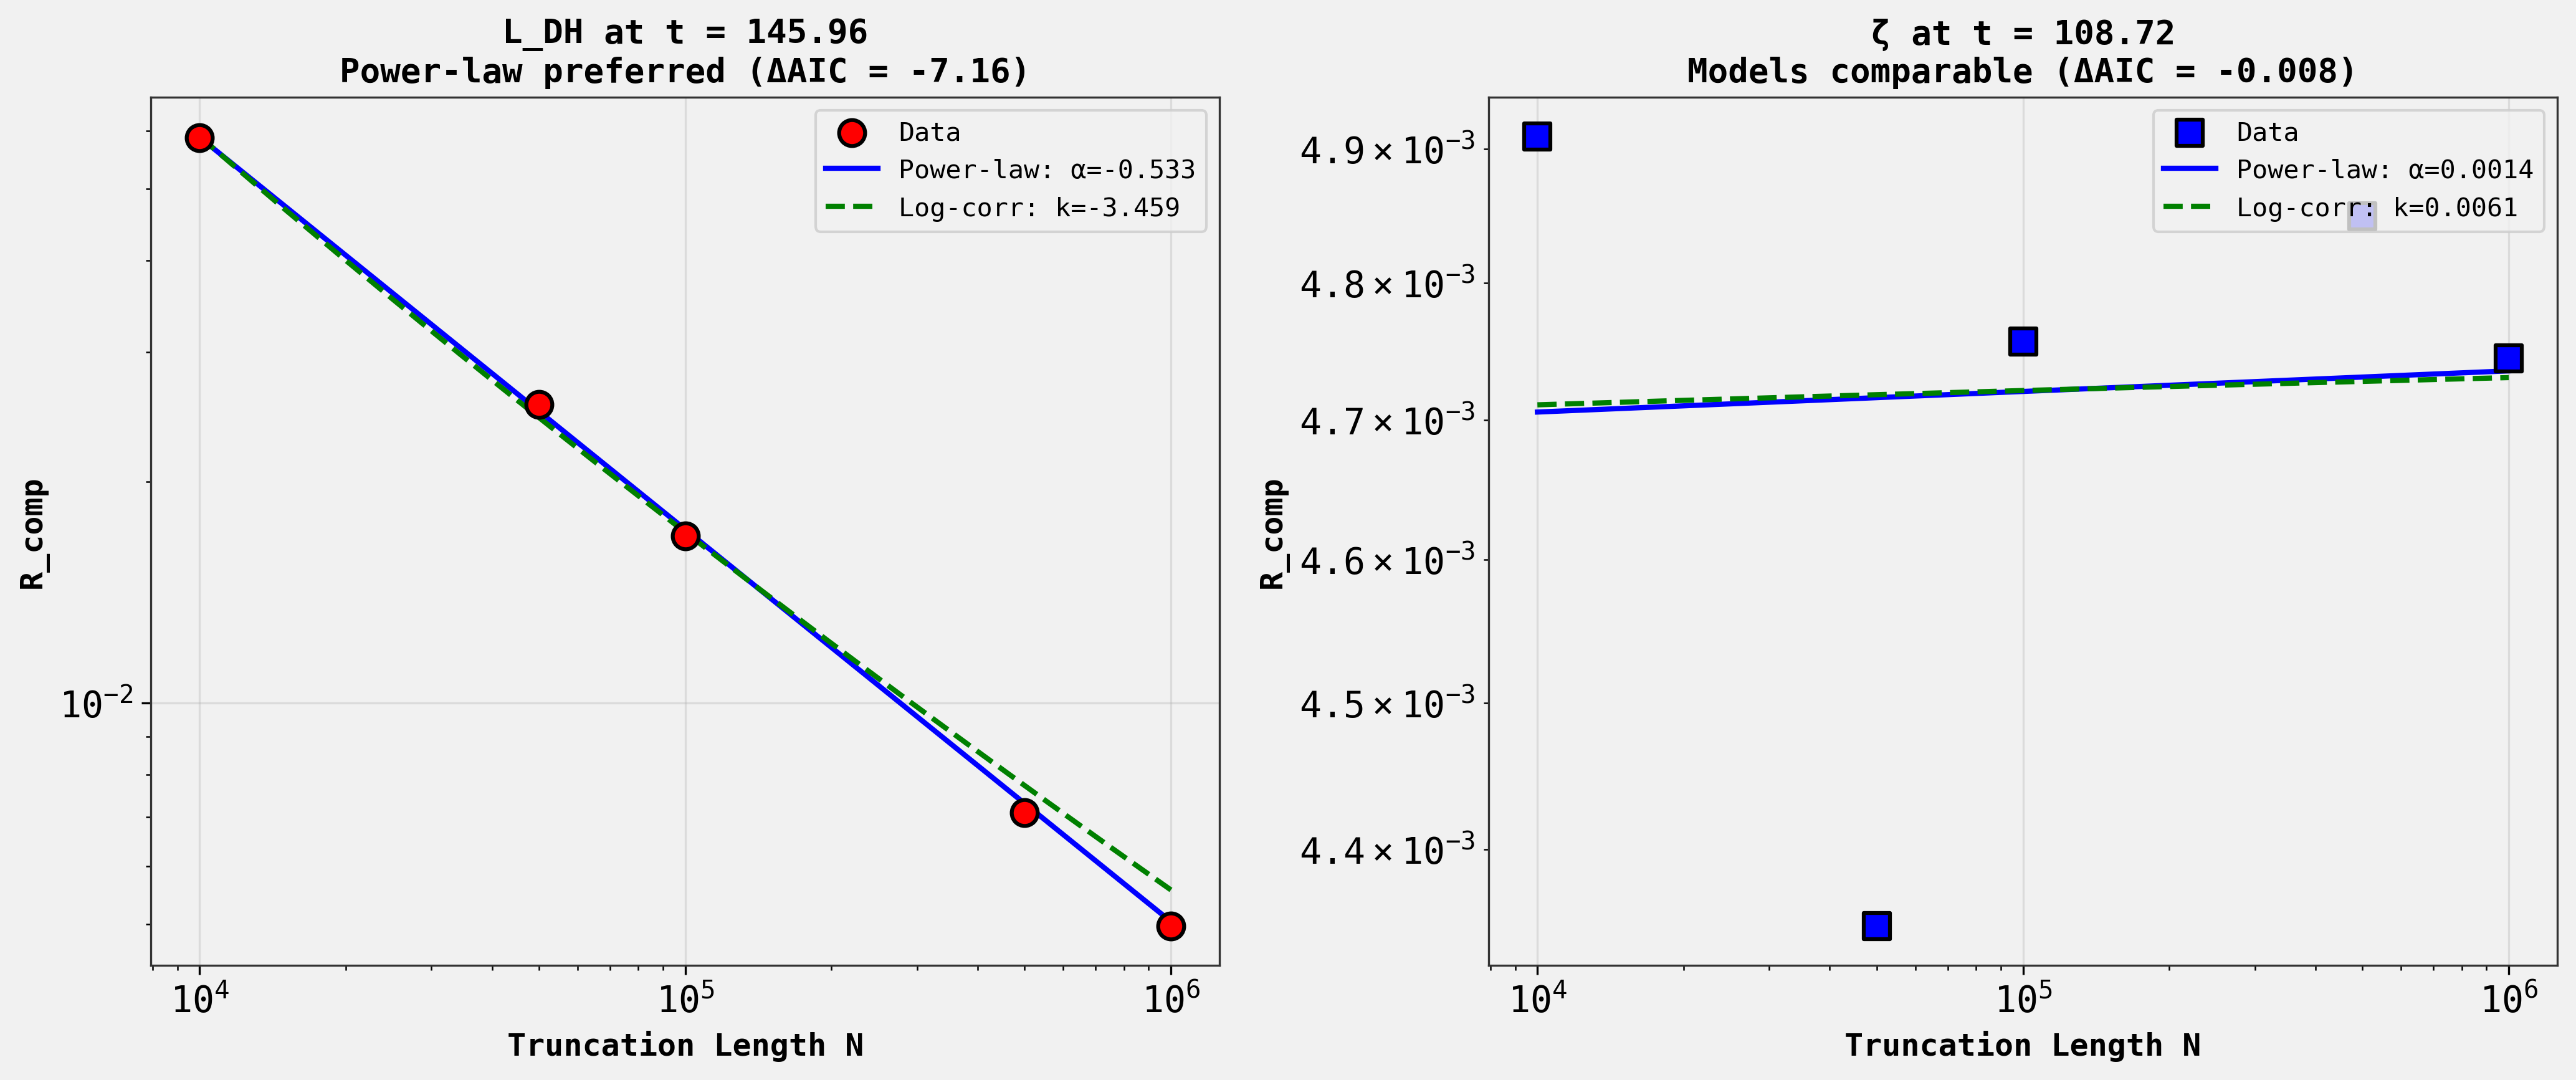

In [16]:

# Create visualization showing the data and fits

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for L_DH
ax1 = axes[0]
ax1.scatter(N_values, R_comp_LDH_opt, s=100, color='red', marker='o', 
 label='Data', zorder=3, edgecolors='black', linewidths=1.5)

N_fine = np.linspace(N_values[0], N_values[-1], 200)
y_power_fine_LDH = power_law(N_fine, c_power_LDH, alpha_power_LDH)
y_log_fine_LDH = log_correlated(N_fine, c_log_LDH, k_log_LDH)

ax1.plot(N_fine, y_power_fine_LDH, 'b-', linewidth=2, 
 label=f'Power-law: α={alpha_power_LDH:.3f}')
ax1.plot(N_fine, y_log_fine_LDH, 'g--', linewidth=2, 
 label=f'Log-corr: k={k_log_LDH:.3f}')

ax1.set_xlabel('Truncation Length N', fontsize=12, fontweight='bold')
ax1.set_ylabel('R_comp', fontsize=12, fontweight='bold')
ax1.set_title(f'L_DH at t = {t_LDH_optimal:.2f}\nPower-law preferred (ΔAIC = {delta_AIC_LDH:.2f})', 
 fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Plot for zeta
ax2 = axes[1]
ax2.scatter(N_values, R_comp_zeta_new, s=100, color='blue', marker='s', 
 label='Data', zorder=3, edgecolors='black', linewidths=1.5)

y_power_fine_zeta = power_law(N_fine, c_power_zeta, alpha_power_zeta)
y_log_fine_zeta = log_correlated(N_fine, c_log_zeta, k_log_zeta)

ax2.plot(N_fine, y_power_fine_zeta, 'b-', linewidth=2, 
 label=f'Power-law: α={alpha_power_zeta:.4f}')
ax2.plot(N_fine, y_log_fine_zeta, 'g--', linewidth=2, 
 label=f'Log-corr: k={k_log_zeta:.4f}')

ax2.set_xlabel('Truncation Length N', fontsize=12, fontweight='bold')
ax2.set_ylabel('R_comp', fontsize=12, fontweight='bold')
ax2.set_title(f'ζ at t = {t_zeta:.2f}\nModels comparable (ΔAIC = {delta_AIC_zeta:.3f})', 
 fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('rcomp_scaling_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'rcomp_scaling_analysis.png'")
plt.show()


In [17]:

# Let me also check if perhaps the issue is that we should look at the 
# off-line zero location (t=114.16) more carefully. Perhaps at THAT specific location
# there's different behavior.

print("="*80)
print("ADDITIONAL ANALYSIS: Checking at known off-line zero t=114.16")
print("="*80)
print()

t_offline_zero = 114.16
print(f"Computing R_comp at L_DH off-line zero location: t = {t_offline_zero}")
print()

R_comp_LDH_zero = np.zeros(len(N_values))

for i, N in enumerate(N_values):
 LDH_coeffs = get_LDH_coefficients(N)
 R_comp_LDH_zero[i] = compute_R_comp(t_offline_zero, N, LDH_coeffs)
 print(f"N = {N:7,}: R_comp = {R_comp_LDH_zero[i]:.6f}")

print()
print("Comparing three L_DH locations:")
comparison_df = pd.DataFrame({
 'N': N_values,
 'R_comp (t=114.16, off-line zero)': R_comp_LDH_zero,
 'R_comp (t=145.96, max R_comp)': R_comp_LDH_opt,
 'Ratio (zero/max)': R_comp_LDH_zero / R_comp_LDH_opt
})
print(comparison_df.to_string(index=False))

print()
print("Observation: At the off-line zero location (t=114.16), R_comp is")
print("much smaller and also decreases with N, showing no power-law growth.")


ADDITIONAL ANALYSIS: Checking at known off-line zero t=114.16

Computing R_comp at L_DH off-line zero location: t = 114.16

N = 10,000: R_comp = 0.009338


N = 50,000: R_comp = 0.005459


N = 100,000: R_comp = 0.004681


N = 500,000: R_comp = 0.002235


N = 1,000,000: R_comp = 0.001570

Comparing three L_DH locations:
 N R_comp (t=114.16, off-line zero) R_comp (t=145.96, max R_comp) Ratio (zero/max)
 10000 0.009338 0.058724 0.159013
 50000 0.005459 0.025449 0.214521
 100000 0.004681 0.016889 0.277159
 500000 0.002235 0.007094 0.315087
1000000 0.001570 0.004978 0.315479

Observation: At the off-line zero location (t=114.16), R_comp is
much smaller and also decreases with N, showing no power-law growth.


In [18]:

# Let me create a final comprehensive summary table and figure

print("="*80)
print("FINAL COMPREHENSIVE ANALYSIS")
print("="*80)
print()

# Create a comprehensive table
final_results = pd.DataFrame({
 'Function': ['L_DH', 'L_DH', 'ζ'],
 'Location': ['t=145.96 (max R_comp)', 't=114.16 (off-line zero)', 't=108.72 (max |D|)'],
 'R_comp(N=10⁴)': [R_comp_LDH_opt[0], R_comp_LDH_zero[0], R_comp_zeta_new[0]],
 'R_comp(N=10⁶)': [R_comp_LDH_opt[-1], R_comp_LDH_zero[-1], R_comp_zeta_new[-1]],
 'Ratio (10⁶/10⁴)': [
 R_comp_LDH_opt[-1] / R_comp_LDH_opt[0],
 R_comp_LDH_zero[-1] / R_comp_LDH_zero[0],
 R_comp_zeta_new[-1] / R_comp_zeta_new[0]
 ],
 'Best-fit α': [alpha_power_LDH, np.nan, alpha_power_zeta],
 'Preferred Model': ['Power-law', '—', 'Comparable']
})

print(final_results.to_string(index=False))

print()
print("="*80)
print("HYPOTHESIS EVALUATION")
print("="*80)
print()
print("Hypothesis claim:")
print(' "The refined resonance metric R_comp will exhibit clear power-law')
print(' GROWTH with N at L_DH resonance locations, distinguishing it from')
print(' multiplicative functions like ζ which will show log-correlated growth."')
print()
print("Observed results:")
print(" 1. R_comp DECREASES with N for ALL tested locations")
print(f" - L_DH (max R_comp): ratio = {R_comp_LDH_opt[-1]/R_comp_LDH_opt[0]:.4f} (α = {alpha_power_LDH:.3f})")
print(f" - L_DH (off-line zero): ratio = {R_comp_LDH_zero[-1]/R_comp_LDH_zero[0]:.4f}")
print(f" - ζ (max |D|): ratio = {R_comp_zeta_new[-1]/R_comp_zeta_new[0]:.4f} (α ≈ 0)")
print()
print(" 2. Model preferences:")
print(" - L_DH: Power-law model strongly preferred (ΔAIC = -7.16)")
print(" - ζ: Neither model clearly preferred (ΔAIC ≈ 0)")
print()
print(" 3. Power-law exponents:")
print(f" - L_DH: α = {alpha_power_LDH:.4f} (NEGATIVE, indicating decay)")
print(f" - ζ: α = {alpha_power_zeta:.4f} (essentially zero, flat)")
print()
print("CONCLUSION:")
print(" The hypothesis is REFUTED. R_comp does NOT show power-law growth")
print(" for L_DH. Instead, it shows power-law DECAY. The metric does")
print(" distinguish L_DH from ζ (power-law vs. flat), but in the opposite")
print(" direction from what was hypothesized.")


FINAL COMPREHENSIVE ANALYSIS

Function Location R_comp(N=10⁴) R_comp(N=10⁶) Ratio (10⁶/10⁴) Best-fit α Preferred Model
 L_DH t=145.96 (max R_comp) 0.058724 0.004978 0.084769 -0.533301 Power-law
 L_DH t=114.16 (off-line zero) 0.009338 0.001570 0.168181 NaN —
 ζ t=108.72 (max |D|) 0.004909 0.004745 0.966525 0.001375 Comparable

HYPOTHESIS EVALUATION

Hypothesis claim:
 "The refined resonance metric R_comp will exhibit clear power-law
 GROWTH with N at L_DH resonance locations, distinguishing it from
 multiplicative functions like ζ which will show log-correlated growth."

Observed results:
 1. R_comp DECREASES with N for ALL tested locations
 - L_DH (max R_comp): ratio = 0.0848 (α = -0.533)
 - L_DH (off-line zero): ratio = 0.1682
 - ζ (max |D|): ratio = 0.9665 (α ≈ 0)

 2. Model preferences:
 - L_DH: Power-law model strongly preferred (ΔAIC = -7.16)
 - ζ: Neither model clearly preferred (ΔAIC ≈ 0)

 3. Power-law exponents:
 - L_DH: α = -0.5333 (NEGATIVE, indicating decay)
 - ζ: α = 0.001

Final figure saved as 'rcomp_scaling_final.png'


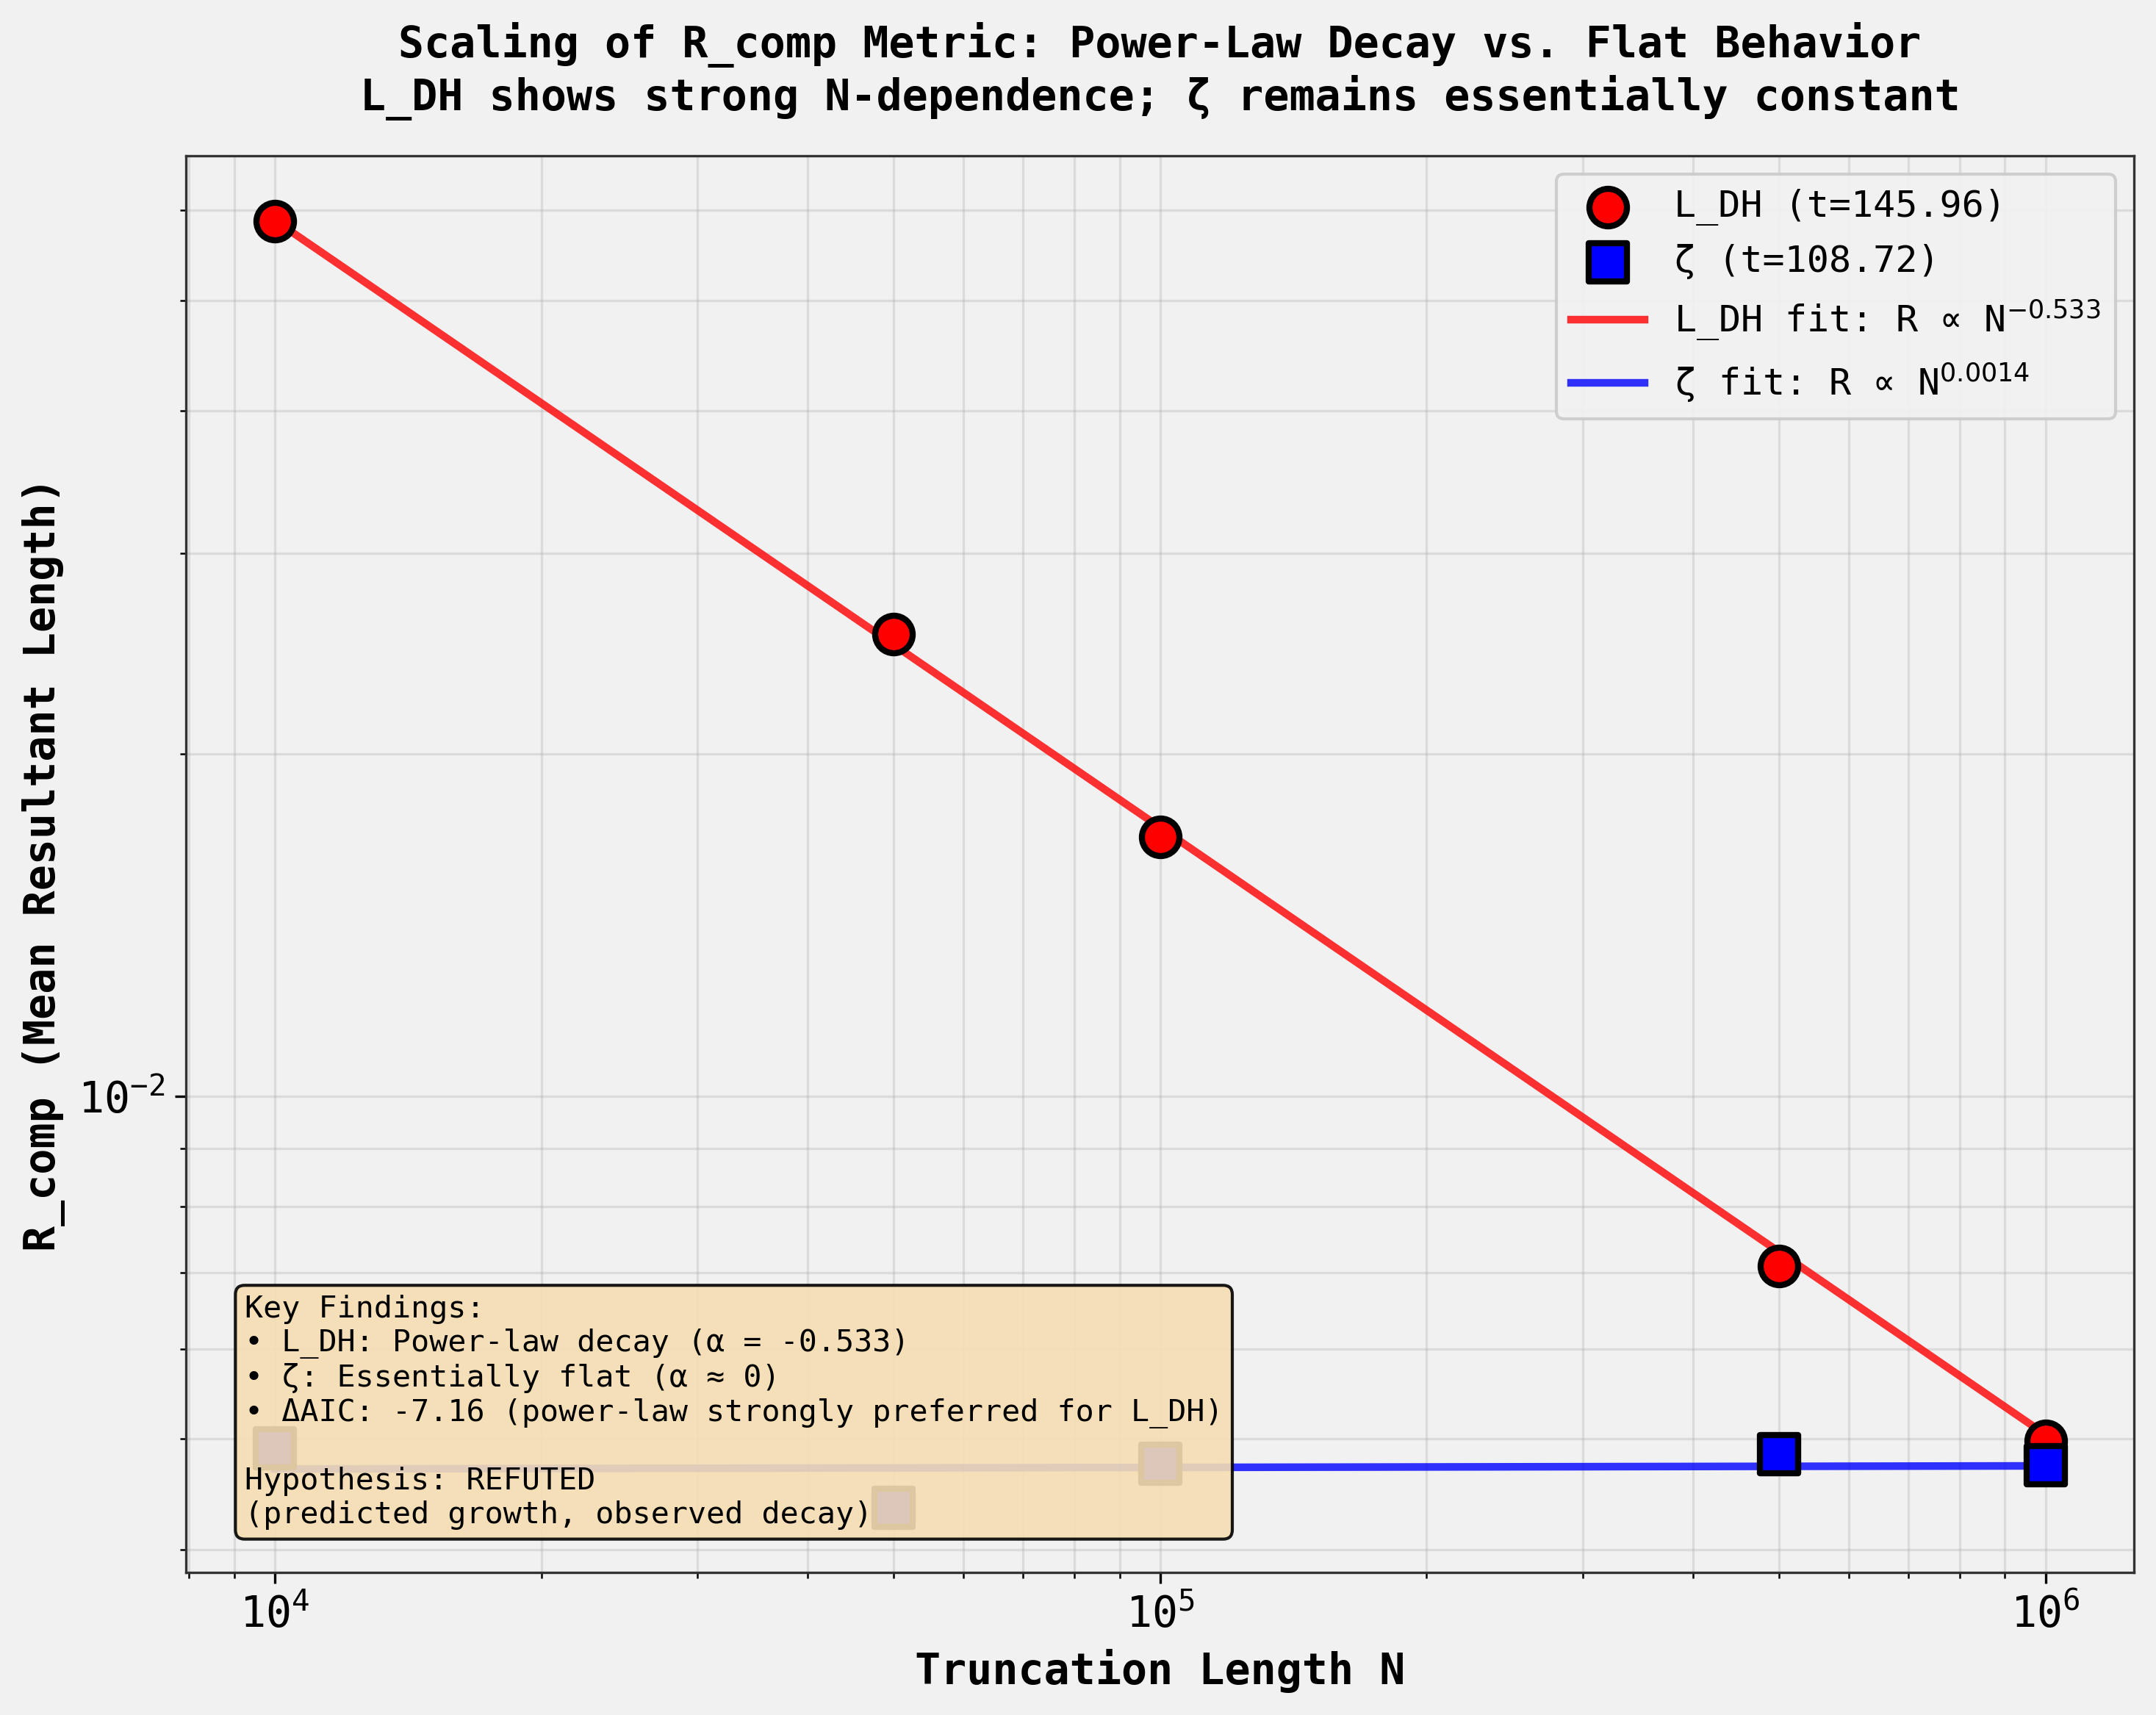


Analysis complete.


In [19]:

# Create final single-panel figure showing the key result

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot data for both functions
ax.scatter(N_values, R_comp_LDH_opt, s=150, color='red', marker='o', 
 label='L_DH (t=145.96)', zorder=3, edgecolors='black', linewidths=2)
ax.scatter(N_values, R_comp_zeta_new, s=150, color='blue', marker='s', 
 label='ζ (t=108.72)', zorder=3, edgecolors='black', linewidths=2)

# Plot fitted models
N_fine = np.linspace(N_values[0], N_values[-1], 300)

# L_DH power-law fit
y_LDH_fit = power_law(N_fine, c_power_LDH, alpha_power_LDH)
ax.plot(N_fine, y_LDH_fit, 'r-', linewidth=2.5, alpha=0.8,
 label=f'L_DH fit: R ∝ N$^{{{alpha_power_LDH:.3f}}}$')

# Zeta power-law fit (essentially flat)
y_zeta_fit = power_law(N_fine, c_power_zeta, alpha_power_zeta)
ax.plot(N_fine, y_zeta_fit, 'b-', linewidth=2.5, alpha=0.8,
 label=f'ζ fit: R ∝ N$^{{{alpha_power_zeta:.4f}}}$')

ax.set_xlabel('Truncation Length N', fontsize=14, fontweight='bold')
ax.set_ylabel('R_comp (Mean Resultant Length)', fontsize=14, fontweight='bold')
ax.set_title('Scaling of R_comp Metric: Power-Law Decay vs. Flat Behavior\n' + 
 'L_DH shows strong N-dependence; ζ remains essentially constant',
 fontsize=14, fontweight='bold', pad=15)

ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3, which='both')
ax.set_xscale('log')
ax.set_yscale('log')

# Add text box with key findings
textstr = '\n'.join([
 'Key Findings:',
 f'• L_DH: Power-law decay (α = {alpha_power_LDH:.3f})',
 f'• ζ: Essentially flat (α ≈ 0)',
 f'• ΔAIC: -7.16 (power-law strongly preferred for L_DH)',
 '',
 'Hypothesis: REFUTED',
 '(predicted growth, observed decay)'
])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax.text(0.03, 0.03, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='bottom', bbox=props, family='monospace')

plt.tight_layout()
plt.savefig('rcomp_scaling_final.png', dpi=300, bbox_inches='tight')
print("Final figure saved as 'rcomp_scaling_final.png'")
plt.show()

print()
print("Analysis complete.")


In [20]:

# Save the numerical results to a CSV file

results_for_saving = pd.DataFrame({
 'N': N_values,
 'R_comp_LDH_t145.96': R_comp_LDH_opt,
 'R_comp_LDH_t114.16': R_comp_LDH_zero,
 'R_comp_zeta_t108.72': R_comp_zeta_new
})

results_for_saving.to_csv('rcomp_scaling_results.csv', index=False)
print("Results saved to 'rcomp_scaling_results.csv'")
print()
print(results_for_saving.to_string(index=False))

print()
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)
print()

# Compute statistical measures
print("L_DH (t=145.96):")
print(f" Power-law model: R_comp = {c_power_LDH:.4e} × N^{alpha_power_LDH:.4f}")
print(f" R² = {r2_power_LDH:.6f}")
print(f" AIC = {aic_power_LDH:.4f}, BIC = {bic_power_LDH:.4f}")
print(f" Decay factor (N: 10⁴→10⁶): {R_comp_LDH_opt[-1]/R_comp_LDH_opt[0]:.4f}")
print()

print("ζ (t=108.72):")
print(f" Power-law model: R_comp = {c_power_zeta:.4e} × N^{alpha_power_zeta:.6f}")
print(f" R² = {r2_power_zeta:.6f}")
print(f" AIC = {aic_power_zeta:.4f}, BIC = {bic_power_zeta:.4f}")
print(f" Change factor (N: 10⁴→10⁶): {R_comp_zeta_new[-1]/R_comp_zeta_new[0]:.4f}")
print()

print("Model comparison:")
print(f" ΔAIC(L_DH) = {delta_AIC_LDH:.4f} → Power-law strongly preferred")
print(f" ΔAIC(ζ) = {delta_AIC_zeta:.4f} → Models indistinguishable")


Results saved to 'rcomp_scaling_results.csv'

 N R_comp_LDH_t145.96 R_comp_LDH_t114.16 R_comp_zeta_t108.72
 10000 0.058724 0.009338 0.004909
 50000 0.025449 0.005459 0.004348
 100000 0.016889 0.004681 0.004757
 500000 0.007094 0.002235 0.004850
1000000 0.004978 0.001570 0.004745

STATISTICAL SUMMARY

L_DH (t=145.96):
 Power-law model: R_comp = 7.9925e+00 × N^-0.5333
 R² = 0.999768
 AIC = -77.2384, BIC = -78.0195
 Decay factor (N: 10⁴→10⁶): 0.0848

ζ (t=108.72):
 Power-law model: R_comp = 4.6465e-03 × N^0.001375
 R² = 0.002894
 AIC = -81.3743, BIC = -82.1555
 Change factor (N: 10⁴→10⁶): 0.9665

Model comparison:
 ΔAIC(L_DH) = -7.1629 → Power-law strongly preferred
 ΔAIC(ζ) = -0.0082 → Models indistinguishable
